In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import special
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy import signal
from scipy.fft import fftshift

import networkx as nx

%matplotlib inline
plt.style.use('seaborn-bright')

/tmp/ipykernel_395820/2486933572.py:16: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [1]:
# resonse function of neurons
def f(x, beta, thresh):
    return 1 / (1 + np.exp(-beta * (x - thresh)))

def F(x, beta, thresh, gamma, sig):
    vmin = -1 / gamma; vmax = 1 / gamma; nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)
    sigmoid_vals = f(x + v, beta, thresh)
    normal_vals = np.exp(-v ** 2 / (2 * sig ** 2)) / np.sqrt(2 * np.pi * sig ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [3]:
gamma = 0.016
beta = 300 * gamma
sigma_ = np.linspace(0.1, 16.25, 50)
U = np.linspace(-30, 30, 1000)

results = np.zeros((len(sigma_), len(U)))

for s0, sigma in enumerate(sigma_):
    for k ,u_val in enumerate(U):
        results[s0, k] = F(u_val, beta, 0.0, gamma, sigma)

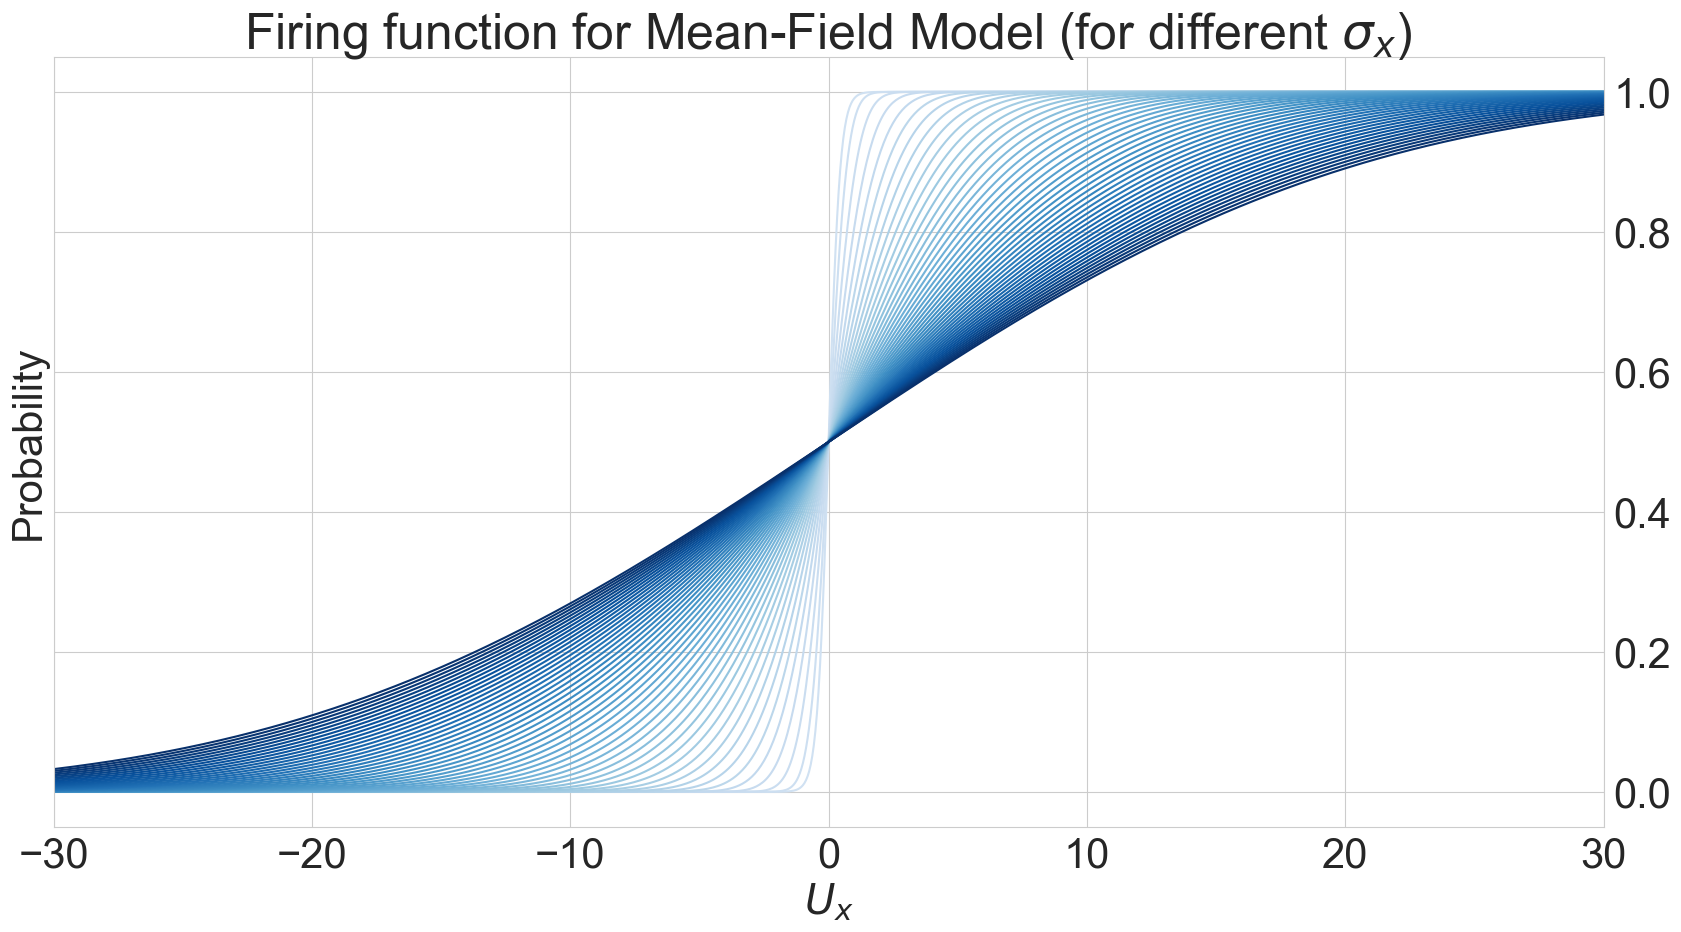

In [5]:
plt.figure(figsize=(20,10))
colormap = plt.cm.gist_ncar
plt.rcParams.update({'font.size': 30})
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, len(sigma_)))))

for s0 in range(0, len(sigma_)):
    plt.plot(U, results[s0, :], label = r'$\sigma$ = ' + f'{sigma_[s0]:.2f}')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
# plt.legend(loc = 'lower left', fontsize=20)
plt.xlim(U[0], U[-1]) 
plt.xlabel(r'$U_x$'); plt.ylabel("Probability")
plt.title('Firing function for Mean-Field Model ' + r'(for different $\sigma_x$)')
plt.show()

In [29]:
T = 500
dt = 0.1
N = 100

D =0.000
Input = np.zeros(T)
response=np.zeros((N,T))

time = np.arange(0,T,1)
heterogeneity = np.zeros(N)

# sigma_x sampling parameters

# Gaussian Distribution: mu - 3 * sigma >= 0
mu = 12; sigma = 3

# Chi-Square Distribution 
chi_dof = 3

# Gamma Distribution: mean = k * theta ; variance = k * theta ^ 2
k = 3.5     # Shape parameter - determine the shape of the distribution
theta = 2   # Scale parameter - controls the spread of the distribution

for i in range(N):
    # heterogeneity[i] = np.random.normal(mu, sigma)
    # heterogeneity[i] = np.random.chisquare(chi_dof, 1)
    heterogeneity[i] = np.random.gamma(k, theta, 1)

heterogeneity = np.sort(heterogeneity)

for t in range(T-1):
 
  if T / 2 < t < T / 2 + 2:
    I = 0.0 + 0.05 / dt
  else:
    I = 0.0
  Input[t+1] = Input[t] + dt * (-Input[t] + I)
  
  for i in range(N):
    response[i][t] = F((Input[t] - 0.05) / gamma, beta, 0.0, gamma, heterogeneity[i])

C:\Users\kgaya\AppData\Local\Temp\ipykernel_16436\472468871.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heterogeneity, kde=True, bins=20, hist=False)


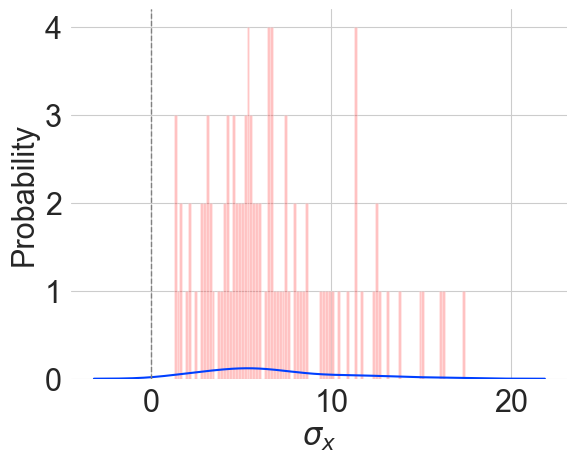

In [30]:
plt.rcParams.update({'font.size': 22})
sns.distplot(heterogeneity, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(heterogeneity, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel(r'$\sigma_x$')
plt.ylabel('Probability')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.show()

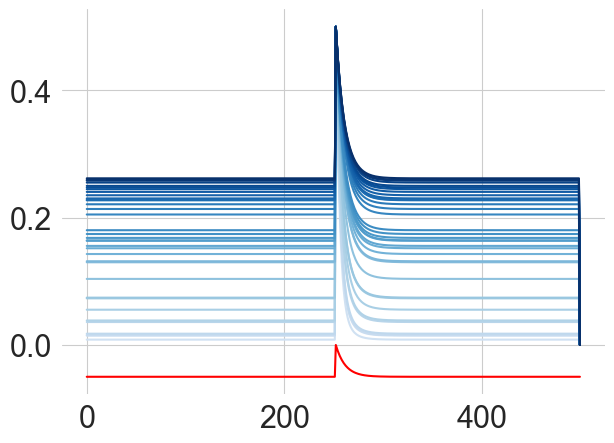

In [34]:
plt.figure(figsize=(7,5))
plt.rcParams.update({'font.size': 22})

mask_idx = np.where(heterogeneity < 5)[0]
mask_het = heterogeneity[mask_idx]
sort_idx = np.argsort(mask_het)

mask_het = mask_het[sort_idx]
mask_response = response[mask_idx, :]
mask_response = mask_response[sort_idx, :]

colormap = plt.cm.gist_ncar
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, len(mask_idx)))))
for i in range(len(mask_idx)):
    plt.plot(time, mask_response[i][:])

plt.plot(time, Input - 0.05, color = 'red')

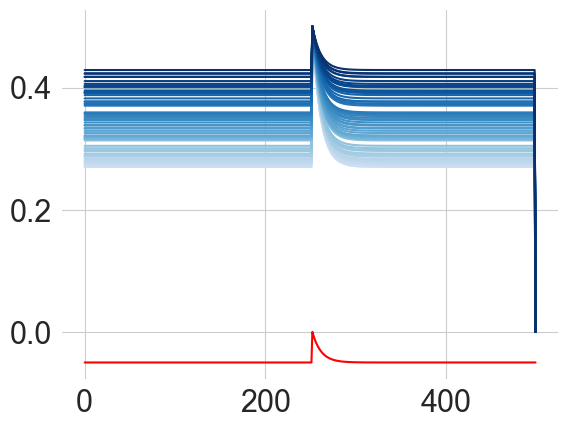

In [35]:
non_mask = np.where(heterogeneity >= 5)[0]
nonmask_het = heterogeneity[non_mask]
sort_idx = np.argsort(nonmask_het)

nonmask_het = nonmask_het[sort_idx]
non_mask_response = response[non_mask, :]
non_mask_response = non_mask_response[sort_idx, :]

colormap = plt.cm.gist_ncar
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, len(non_mask)))))
for i in range(len(non_mask)):
    plt.plot(time, non_mask_response[i][:])

plt.plot(time, Input - 0.05, color = 'red')

In [20]:
v_min = -1 / gamma
v_max = 1 / gamma
nConv = 1000

dv = np.abs(v_max - v_min) / nConv
u_val = (0 + 0.03) / gamma
u_bar = np.zeros(len(heterogeneity))

v_vals = []
f_vals = []

for k in range(len(heterogeneity)):
    sigma_x = heterogeneity[k]
    for i in range(nConv):
        v = v_min + i * dv; v_vals.append(v)
        f_val = f(u_val + v, beta, 0.0); f_vals.append(f_val)
        u_bar[k] += dv * f_val * np.exp(-v**2 / (2 * sigma_x ** 2)) / np.sqrt(2 * np.pi * sigma_x ** 2)
                                                                    
v_vals = np.array(v_vals)
f_vals = np.array(f_vals)

C:\Users\kgaya\AppData\Local\Temp\ipykernel_4720\3118493370.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


C:\Users\kgaya\AppData\Local\Temp\ipykernel_4720\4277399037.py:19: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(u_bar[k], 1, '-', label = r"$\sigma_x$ = " + f"{heterogeneity[k]:.3f}", use_line_collection = True)


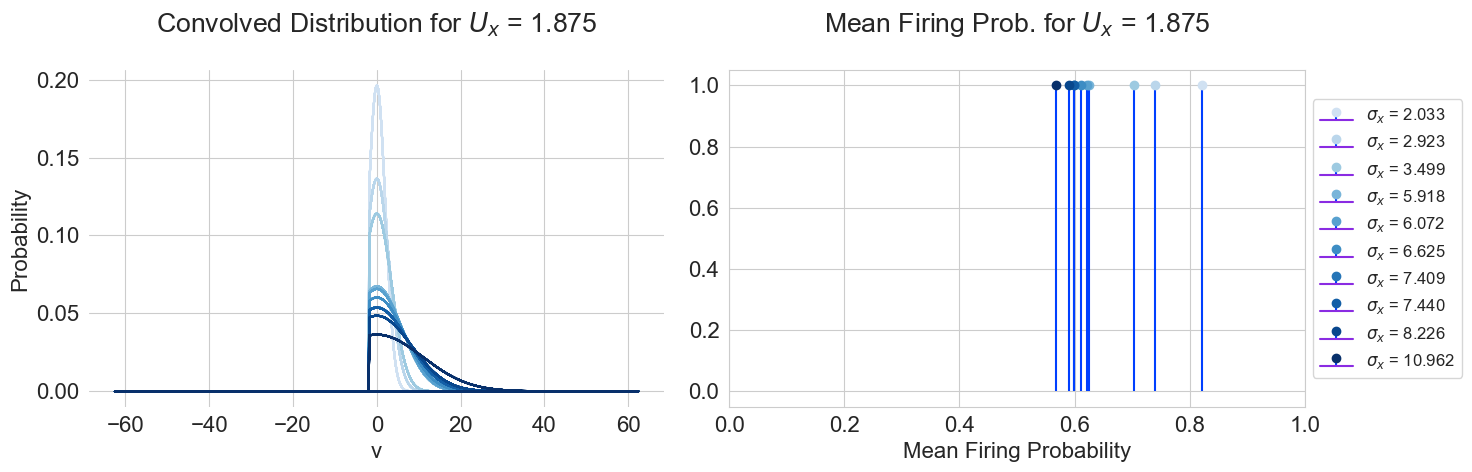

In [21]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.subplot(1, 2, 1)
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, len(heterogeneity)))))
for k in range(len(heterogeneity)):
    sigma_x = heterogeneity[k]
    plt.plot(v_vals, f_vals * np.exp(-v_vals ** 2 / (2 * sigma_x ** 2)) / np.sqrt(2 * np.pi * sigma_x ** 2))

plt.xlabel('v'); plt.ylabel('Probability')
plt.title(r'Convolved Distribution for $U_x$ = ' + f'{u_val:.3f}\n')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)

plt.subplot(1, 2, 2)
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, len(heterogeneity)))))

for k in range(len(heterogeneity)):
    plt.stem(u_bar[k], 1, '-', label = r"$\sigma_x$ = " + f"{heterogeneity[k]:.3f}", use_line_collection = True)
plt.xlabel('Mean Firing Probability')
plt.xlim([0, 1]); plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.title(r'Mean Firing Prob. for $U_x$ = ' + f'{u_val:.3f}\n')

plt.tight_layout()
plt.show()